In [1]:
import pandas as pd

In [10]:
df = pd.read_csv("Datasets/cleaned_data.csv", keep_default_na=False)
df.isnull().sum()

title           0
text            0
subject         0
date            0
authenticity    0
text_len        0
clean_text      0
dtype: int64

In [11]:
print((df['clean_text']=="").sum())

716


In [12]:
df['clean_text'] = df['clean_text'].apply(lambda x: "" if str(x).strip()=="" else x)

In [13]:
df['clean_text'].isna().sum()   

0

In [14]:
import os

In [15]:
print('cwd: ', os.getcwd())

cwd:  D:\Github Projects\fake-news-detector-ml


In [18]:
print("rows:", len(df))
print("columns:", df.columns.tolist())
print("nulls per column:\n", df.isna().sum())
print("empty clean_text strings:", (df['clean_text'].astype(str).str.strip()=="").sum())
print("fake and real counts:\n", df['authenticity'].value_counts())

rows: 44689
columns: ['title', 'text', 'subject', 'date', 'authenticity', 'text_len', 'clean_text']
nulls per column:
 title           0
text            0
subject         0
date            0
authenticity    0
text_len        0
clean_text      0
dtype: int64
empty clean_text strings: 716
fake and real counts:
 authenticity
0    23478
1    21211
Name: count, dtype: int64


In [19]:
import re
import string
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [20]:
if 'label' not in df.columns and 'authenticity' in df.columns:
    df.rename(columns={'authenticity':'label'}, inplace=True)
df['label'] = df['label'].astype(int)

In [22]:
X = df['clean_text']
y = df['label']
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state = 42,stratify = y)

## TF-IDF

In [23]:
tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2),stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print("TF-IDF shape:", X_train_tfidf.shape)

TF-IDF shape: (35751, 20000)


## Model

In [24]:
model = LogisticRegression(max_iter=2000)
model.fit(X_train_tfidf,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


## Model Evaluation

In [25]:
y_pred = model.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.4f}\n")
print("Classification report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9871

Classification report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99      4696
           1       0.98      0.99      0.99      4242

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



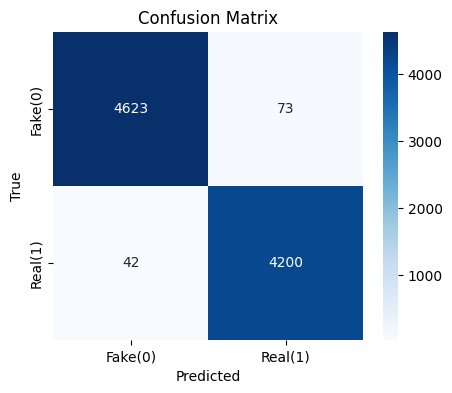

In [26]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fake(0)','Real(1)'], yticklabels=['Fake(0)','Real(1)'])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

## Saving Model

In [27]:
joblib.dump({
    "model": model,
    "tfidf": tfidf,
}, "fake_news_pipeline.pkl")

['fake_news_pipeline.pkl']